<div style="
background: linear-gradient(90deg, #6F4E37, #C4A484);
padding:25px;
border-radius:15px;
text-align:center;
color:white;
box-shadow: 4px 4px 10px rgba(0,0,0,0.3);">

<h1>☕ Coffee Shop Sales Analysis</h1>
<h3>Data Analytics Project using Python</h3>
<p>Exploring Sales Trends, Customer Behavior & Business Insights</p>

</div>

<div style="
background-color:#F5F5DC;
padding:15px;
border-left:8px solid #6F4E37;
border-radius:8px;">

<h3>📂 Dataset Information</h3>

<ul>
<li>Source: Coffee Shop Sales Dataset</li>
<li>Total Records: 149107</li>
<li>Columns: 16</li>
<li>Period Covered: 3 days</li>
</ul>

</div>

<div style="
background-color linear-gradient(90deg, #6F4E37, #C4A484);
padding:15px;
border-radius:10px;">

<h2>🎯 Project Objectives</h2>

<ul>
<li>Analyze overall sales performance.</li>
<li>Identify best-selling products.</li>
<li>Determine peak sales hours.</li>
<li>Discover monthly sales trends.</li>
<li>Provide actionable business insights.</li>
</ul>

</div>

<div style="
background-color:#1565C0;
padding:12px;
border-radius:8px;
color:white;">

<h2>📊 Exploratory Data Analysis (EDA)</h2>

</div>

In [4]:
import pandas as pd
import numpy as np

In [5]:
import matplotlib.pyplot as plt
import plotly.express as px

<div style="
background-color:#1565C0;
padding:10px;
border-radius:6px;
color:white;
text-align:center;">
<h2>Data Loading & Inspection</h2>

</div>

In [6]:
df = pd.read_excel("G:\\project ali\\PROJECT FILES\\Coffee Shop Sales raw.xlsx")

In [7]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149169 entries, 0 to 149168
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149169 non-null  int64         
 1   transaction_date  149165 non-null  datetime64[ns]
 2   transaction_time  149169 non-null  object        
 3   transaction_qty   149169 non-null  int64         
 4   store_id          149169 non-null  int64         
 5   store_location    149169 non-null  object        
 6   product_id        149169 non-null  int64         
 7   unit_price        149169 non-null  float64       
 8   product_category  149166 non-null  object        
 9   product_type      149169 non-null  object        
 10  product_detail    149167 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [9]:
df.shape

(149169, 11)

In [10]:
df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149169.000000,149165,149169.000000,149169.000000,149169.000000,149169.000000
mean,74763.910290,2023-04-15 12:26:15.200616960,1.438281,5.341928,47.917040,3.382307
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37349.000000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74754.000000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112134.000000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43168.890055,NaN,0.542494,2.074376,17.929508,2.658714


In [11]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail'],
      dtype='object')

<h2 style="color:#8B4513;">Data Cleaning</h2>

<h2 style="color:#8B4513;">1 - Duplicate Removal</h2>

In [12]:
df.duplicated().sum()

53

In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

0

<h2 style="color:#8B4513;">2 - Null Values Handling</h2>

In [15]:
df.isna().sum()

transaction_id      0
transaction_date    4
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    3
product_type        0
product_detail      2
dtype: int64

In [16]:
#Here only few rows have empty/null values so we decided to delete them.
df.dropna()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino


In [17]:
#After droping the null rows we saved it into the dataframe.
df = df.dropna()

In [18]:
df.isna().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

<h2 style="color:#8B4513;">3 - Checking Datatypes</h2>

In [19]:
df.dtypes

transaction_id               int64
transaction_date    datetime64[ns]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
dtype: object

In [20]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


<h2 style="color:#8B4513;">4 - Formating the Rows</h2>

In [21]:
# Column 'Store_location'

df['store_location'].unique()

array(['Lower Manhattan', "Hell's Kitchen", 'Astoria'], dtype=object)

In [22]:
df['store_location'].str.strip().str.title()

0         Lower Manhattan
1         Lower Manhattan
2         Lower Manhattan
3         Lower Manhattan
4         Lower Manhattan
               ...       
149111     Hell'S Kitchen
149112     Hell'S Kitchen
149113     Hell'S Kitchen
149114     Hell'S Kitchen
149115     Hell'S Kitchen
Name: store_location, Length: 149107, dtype: object

In [23]:
df['store_location'] = df['store_location'].str.strip().str.title()

In [24]:
# Column 'product_category'
df['product_category'].unique()

array(['Coffee', 'Tea', 'Drinking Chocolate', 'Bakery', 'Flavours',
       'Loose Tea', 'Coffee beans', 'Packaged Chocolate', 'Branded',
       'coffee', 'bakery', 'tea', 'flavours'], dtype=object)

In [25]:
df['product_category'].str.strip().str.title()

0                     Coffee
1                        Tea
2         Drinking Chocolate
3                     Coffee
4                        Tea
                 ...        
149111                   Tea
149112                   Tea
149113                   Tea
149114                Coffee
149115              Flavours
Name: product_category, Length: 149107, dtype: object

In [26]:
df['product_category'] = df['product_category'].str.strip().str.title()

In [27]:
# Column 'product_type'
df['product_type'].unique()

array(['Gourmet brewed coffee', 'Brewed Chai tea', 'Hot chocolate',
       'Drip coffee', 'Scone', 'Barista Espresso', 'Brewed Black tea',
       'Brewed Green tea', 'Brewed herbal tea', 'Biscotti', 'Pastry',
       'Organic brewed coffee', 'Premium brewed coffee', 'SCONE',
       'Regular syrup', 'Herbal tea', 'Gourmet Beans', 'Organic Beans',
       'Sugar free syrup', 'Drinking Chocolate', 'Premium Beans',
       'Chai tea', 'Green beans', 'Espresso Beans', 'Green tea',
       'Organic Chocolate', 'Housewares', 'Black tea',
       'House blend Beans', 'Clothing', 'drip coffee', 'hot chocolate',
       'pastry'], dtype=object)

In [28]:
df['product_type'].str.strip().str.title()

0         Gourmet Brewed Coffee
1               Brewed Chai Tea
2                 Hot Chocolate
3                   Drip Coffee
4               Brewed Chai Tea
                  ...          
149111        Brewed Herbal Tea
149112         Brewed Black Tea
149113        Brewed Herbal Tea
149114         Barista Espresso
149115            Regular Syrup
Name: product_type, Length: 149107, dtype: object

In [29]:
df['product_type'] = df['product_type'].str.strip().str.title()

In [30]:
# Column 'product_detail'
df['product_detail'].unique()

array(['Ethiopia Rg', 'Spicy Eye Opener Chai Lg', 'Dark chocolate Lg',
       'Our Old Time Diner Blend Sm', 'Oatmeal Scone',
       'Columbian Medium Roast Sm', 'Latte Rg', 'Dark chocolate Rg',
       'Spicy Eye Opener Chai Rg', 'Ethiopia Lg', 'Earl Grey Lg',
       'Ouro Brasileiro shot', 'Serenity Green Tea Lg',
       'Jumbo Savory Scone', 'Lemon Grass Rg',
       'Sustainably Grown Organic Lg', 'Hazelnut Biscotti', 'Cappuccino',
       'Lemon Grass Lg', 'Chocolate Chip Biscotti', 'Peppermint Lg',
       'Chocolate Croissant', 'Latte', 'Brazilian Rg', 'Brazilian Lg',
       'Columbian Medium Roast Rg', 'Morning Sunrise Chai Rg',
       'Morning Sunrise Chai Lg', 'Our Old Time Diner Blend Lg',
       'Sustainably Grown Organic Rg', 'Scottish Cream Scone ',
       'Peppermint Rg', 'English Breakfast Rg',
       'Our Old Time Diner Blend Rg', 'Serenity Green Tea Rg',
       'Brazilian Sm', 'Jamaican Coffee River Sm',
       'Jamaican Coffee River Lg', 'Ginger Biscotti',
       'Tradit

In [31]:
df['product_detail'].str.strip().str.title()

0                         Ethiopia Rg
1            Spicy Eye Opener Chai Lg
2                   Dark Chocolate Lg
3         Our Old Time Diner Blend Sm
4            Spicy Eye Opener Chai Lg
                     ...             
149111                  Peppermint Rg
149112           English Breakfast Lg
149113                  Peppermint Lg
149114                     Cappuccino
149115                 Hazelnut Syrup
Name: product_detail, Length: 149107, dtype: object

In [32]:
df['product_detail'] = df['product_detail'].str.strip().str.title()

<h2 style="color:#8B4513;">Creating New Columns</h2>

In [33]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet Brewed Coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai Tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot Chocolate,Dark Chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip Coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai Tea,Spicy Eye Opener Chai Lg


In [34]:
# Here we created a new column as ' sales ' because we already had transation_qty and unit_price in dataset.

df['sales'] = df['transaction_qty'] * df['unit_price']
df['sales']

0         6.00
1         6.20
2         9.00
3         2.00
4         6.20
          ... 
149111    5.00
149112    6.00
149113    3.00
149114    3.75
149115    1.60
Name: sales, Length: 149107, dtype: float64

<h2 style="color:#8B4513;">Extract month_name</h2>

In [35]:
# Extract month_name
df['month_name'] = df ['transaction_date'].dt.month_name()
df['month_name']

0         January
1         January
2         January
3         January
4         January
           ...   
149111       June
149112       June
149113       June
149114       June
149115       June
Name: month_name, Length: 149107, dtype: object

# Extract day_name


In [36]:
# Extract day_name
df['day_name'] = df ['transaction_date'].dt.day_name()
df['day_name']

0         Sunday
1         Sunday
2         Sunday
3         Sunday
4         Sunday
           ...  
149111    Friday
149112    Friday
149113    Friday
149114    Friday
149115    Friday
Name: day_name, Length: 149107, dtype: object

# Extract hour

In [37]:
# Extract hour
df['hour'] = pd.to_datetime(df['transaction_time'].astype(str)).dt.hour
df['hour']

C:\Users\Lecturer Computer\AppData\Local\Temp\ipykernel_11356\526545411.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour'] = pd.to_datetime(df['transaction_time'].astype(str)).dt.hour


0          7
1          7
2          7
3          7
4          7
          ..
149111    20
149112    20
149113    20
149114    20
149115    20
Name: hour, Length: 149107, dtype: int32

In [38]:
# Extract year
df['year'] = df ['transaction_date'].dt.year
df['year']

0         2023
1         2023
2         2023
3         2023
4         2023
          ... 
149111    2023
149112    2023
149113    2023
149114    2023
149115    2023
Name: year, Length: 149107, dtype: int32

In [39]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,sales,month_name,day_name,hour,year
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet Brewed Coffee,Ethiopia Rg,6.0,January,Sunday,7,2023
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai Tea,Spicy Eye Opener Chai Lg,6.2,January,Sunday,7,2023
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot Chocolate,Dark Chocolate Lg,9.0,January,Sunday,7,2023
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip Coffee,Our Old Time Diner Blend Sm,2.0,January,Sunday,7,2023
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai Tea,Spicy Eye Opener Chai Lg,6.2,January,Sunday,7,2023


# Sales Analysis



# (a) Total Sales


In [40]:
df['sales'].sum().round()

698774.0

# (b) Average Sale

In [41]:
df['sales'].mean().round()

5.0

# (c) Total Transactions

In [42]:
df['transaction_id'].nunique()

149107

# Product Categories

In [43]:
df['product_category'].value_counts()

product_category
Coffee                58414
Tea                   45448
Bakery                22791
Drinking Chocolate    11467
Flavours               6790
Coffee Beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487
Name: count, dtype: int64

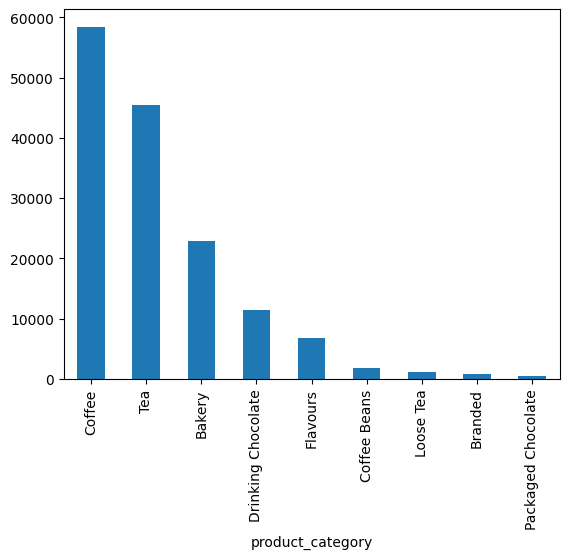

In [44]:
df['product_category'].value_counts().plot(kind='bar')
plt.show()

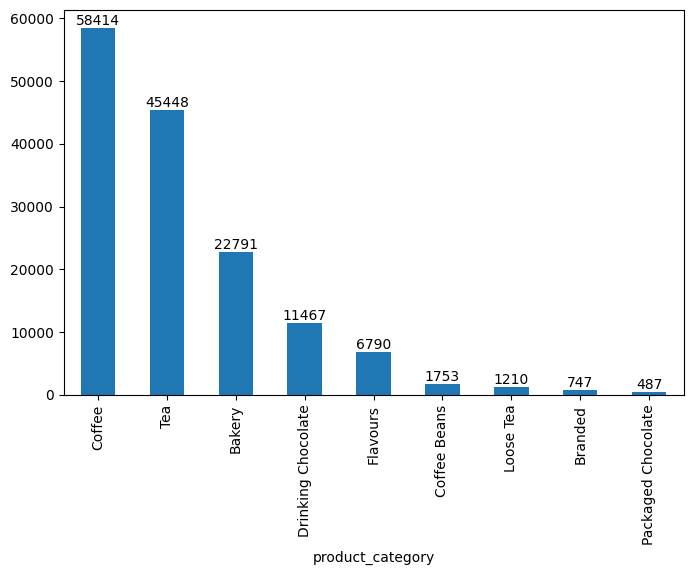

In [45]:
plt.figure(figsize=(8,5))
ax = df['product_category'].value_counts().plot(kind='bar')

ax.bar_label(ax.containers[0])

plt.show()

# Monthly Sales Trend


In [46]:
monthly_sales = df.groupby(by = 'month_name')['sales'].sum().sort_values(ascending = False).reset_index()
monthly_sales


,month_name,sales
0,June,166447.18
1,May,156727.76
2,April,118941.08
3,March,98834.68
4,January,81677.74
5,February,76145.19


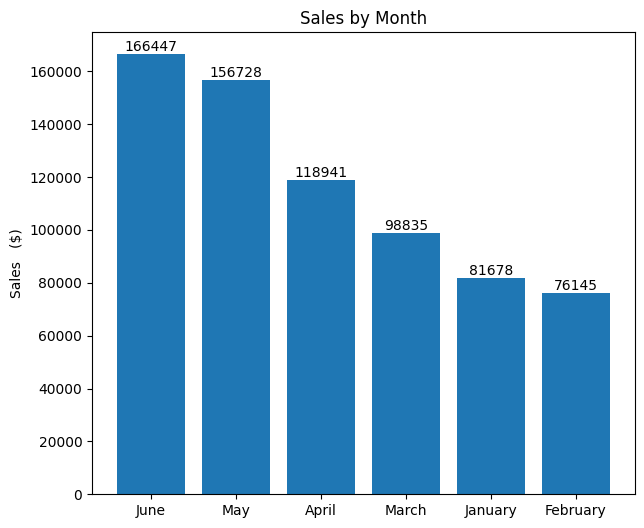

In [47]:
plt.figure(figsize=(7,6))

bars = plt.bar(
    monthly_sales['month_name'],
    monthly_sales['sales']
)

plt.bar_label(bars, fmt='%.0f')
plt.title("Sales by Month")
plt.ylabel("Sales   ($)")
plt.show()

#  Store Performance

In [48]:
store_performance = df.groupby(by = 'store_location')['sales'].sum().sort_values(ascending = False).reset_index()
store_performance

,store_location,sales
0,Hell'S Kitchen,236503.92
1,Astoria,232234.66
2,Lower Manhattan,230035.05


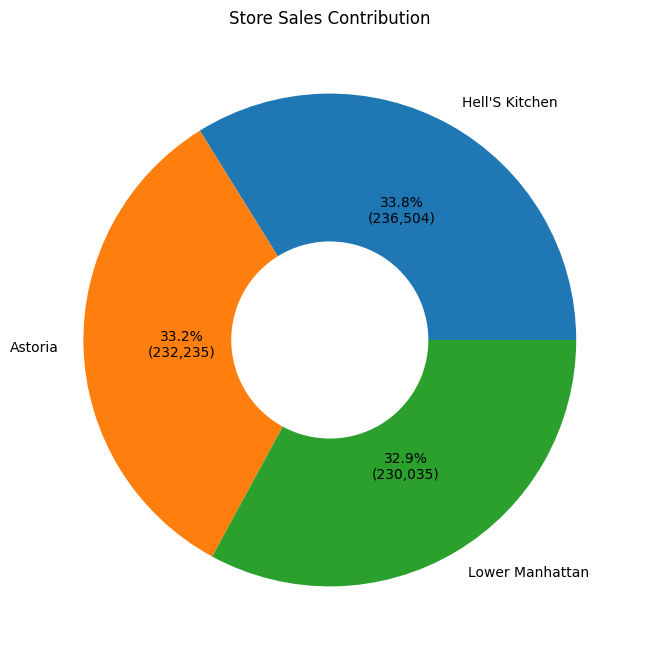

In [49]:
sales = store_performance['sales']
labels = store_performance['store_location']

# Function to show percentage and actual value
def show_percentage_and_value(pct):
    total = sales.sum()
    value = int(round(pct * total / 100))
    return f'{pct:.1f}%\n({value:,})'

plt.figure(figsize=(8,8))

plt.pie(
    sales,
    labels=labels,
    autopct=show_percentage_and_value,
    wedgeprops={'width': 0.6}  # Doughnut chart
)

plt.title('Store Sales Contribution')
plt.show()

# Sales by Product Category

In [50]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,sales,month_name,day_name,hour,year
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet Brewed Coffee,Ethiopia Rg,6.0,January,Sunday,7,2023
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai Tea,Spicy Eye Opener Chai Lg,6.2,January,Sunday,7,2023
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot Chocolate,Dark Chocolate Lg,9.0,January,Sunday,7,2023
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip Coffee,Our Old Time Diner Blend Sm,2.0,January,Sunday,7,2023
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai Tea,Spicy Eye Opener Chai Lg,6.2,January,Sunday,7,2023


In [51]:
product_type_sales = df.groupby(by = 'product_type')['sales'].sum().sort_values(ascending = False).reset_index().head(10)
product_type_sales

,product_type,sales
0,Barista Espresso,91406.20
1,Brewed Chai Tea,77081.95
2,Hot Chocolate,72407.00
3,Gourmet Brewed Coffee,70034.60
4,Brewed Black Tea,47932.00
5,Brewed Herbal Tea,47536.50
6,Premium Brewed Coffee,38781.15
7,Organic Brewed Coffee,37744.30
8,Scone,36861.62
9,Drip Coffee,31978.00


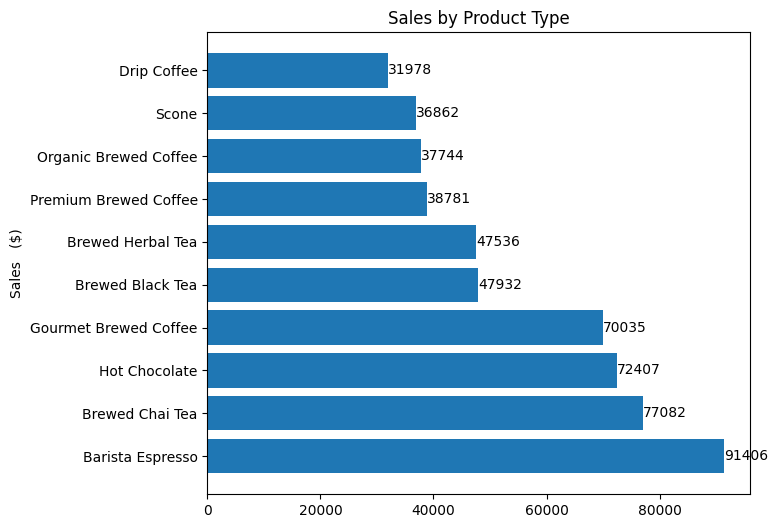

In [52]:
plt.figure(figsize=(7,6))

bars = plt.barh(
    product_type_sales['product_type'],
    product_type_sales['sales']
)

plt.bar_label(bars, fmt='%.0f')
plt.title("Sales by Product Type")
plt.ylabel("Sales   ($)")
plt.show()

# Sales by Hour 



In [53]:
sales_hour = df.groupby(by = 'hour')['sales'].sum().reset_index()
sales_hour

,hour,sales
0,6,21900.27
1,7,63526.47
2,8,82676.92
3,9,85169.53
4,10,88657.64
5,11,46319.14
6,12,40192.79
7,13,40367.45
8,14,41304.74
9,15,41733.10


In [54]:
px.line(sales_hour,x="hour",y="sales")

In [55]:
sales_hour.head()
sales_hour.tail()

,hour,sales
10,16,41122.75
11,17,40134.31
12,18,34286.20
13,19,28446.68
14,20,2935.64


In [56]:
day_sales = df.groupby('day_name')['sales'].sum().reset_index()
day_sales

,day_name,sales
0,Friday,101334.30
1,Monday,101677.28
2,Saturday,96894.48
3,Sunday,98330.31
4,Thursday,100767.78
5,Tuesday,99455.94
6,Wednesday,100313.54


In [57]:
px.line(day_sales,x="day_name",y="sales")


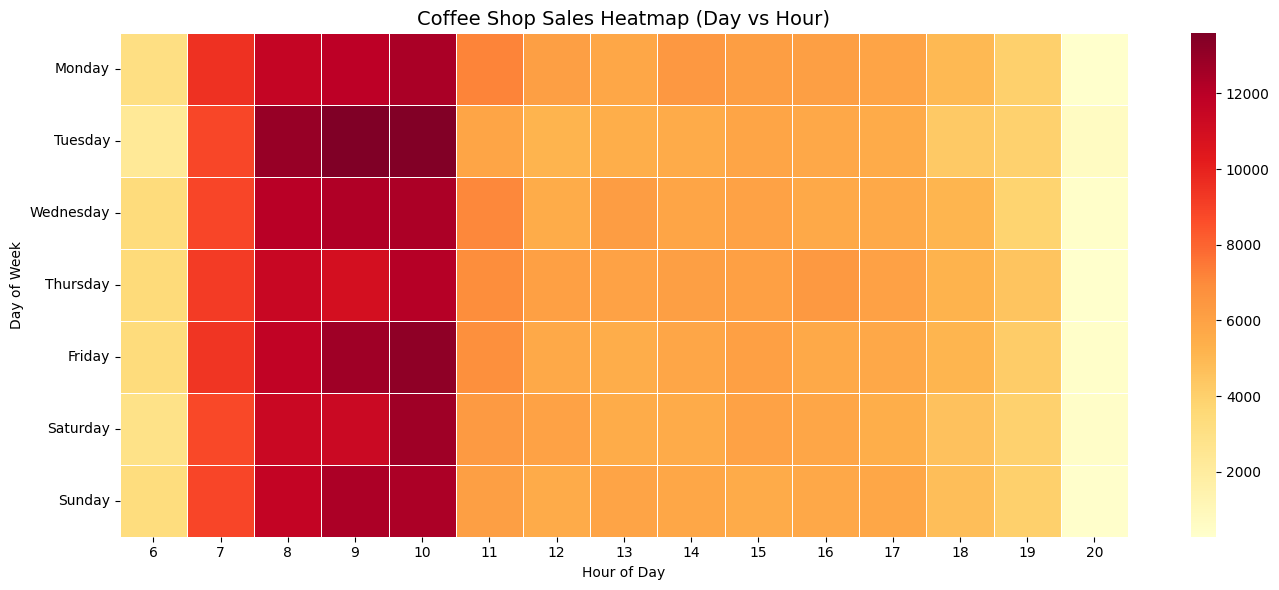

In [58]:
import seaborn as sns

heatmap_data = pd.pivot_table(
    df,
    values='sales',
    index='day_name',
    columns='hour',
    aggfunc='sum'
)

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white'
)

plt.title('Coffee Shop Sales Heatmap (Day vs Hour)', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')

plt.tight_layout()
plt.show()

<div style="
background-color:#FFF3CD;
padding:15px;
border-radius:10px;
border-left:8px solid #FFC107;">

<h2>🔍 Key Findings</h2>

<ul>
<li>Morning hours generate the highest sales.</li>
<li>Coffee contributes the largest revenue share.</li>
<li>Weekends show increased customer traffic.</li>
<li>Certain product categories outperform others.</li>
</ul>


<div style="
background-color:#D4EDDA;
padding:15px;
border-radius:10px;
border-left:8px solid green;">

<h2>💡 Recommendations</h2>

<ul>
<li>Increase inventory during peak hours.</li>
<li>Promote low-performing products.</li>
<li>Introduce combo offers on weekends.</li>
<li>Focus marketing on top-selling categories.</li>
</ul>

</div>

<div style="
background: linear-gradient(90deg,#4CAF50,#81C784);
padding:20px;
border-radius:10px;
text-align:center;
color:white;">

<h2>✅ Analysis Completed Successfully</h2>

<h4>Insights Generated • Visualizations Created • Recommendations Provided</h4>

</div>